In [1]:
import numpy as np

#Define network

이전 주차의 TwoLayerNet에서 레이어 수, 가중치 초기화 및 감소, dropout, batchnorm 기능을 추가하였습니다.

**self.__init_weight()**과 **self.loss()**의 빈칸을 채워주세요!

In [17]:
from collections import OrderedDict

class MultiLayerNet:
    '''
    input_size: 입력 크기 (MNIST의 경우 784)
    hidden_size_list: 은닉층 뉴런 개수의 리스트 (예: [100,100,100])
    output_size: 출력 크기 (MNIST의 경우 10)
    activation: 'relu' 또는 'sigmoid'
    weight_init_std: 가중치의 표준 편차 지정 (예: 0.01)
    'relu' 또는 'he'를 지정하면 He 초기화를 설정
    'sigmoid' 또는 'xavier'를 지정하면 Xavier 초기화를 설정
    weight_decay_lambda: Weight Decay(L2 정규화)의 강도
    use_dropout: Dropout을 사용할지 여부
    dropout_ration: Dropout 비율
    use_batchNorm: Batch Normalization을 사용할지 여부
    '''

    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0,
                 use_dropout = False, dropout_ration = 0.5, use_batchnorm=False):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.use_dropout = use_dropout
        self.weight_decay_lambda = weight_decay_lambda
        self.use_batchnorm = use_batchnorm
        self.params = {}

        self.__init_weight(weight_init_std)

        # 레이어 생성
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            if self.use_batchnorm:
                self.params['gamma' + str(idx)] = np.ones(hidden_size_list[idx-1])
                self.params['beta' + str(idx)] = np.zeros(hidden_size_list[idx-1])
                self.layers['BatchNorm' + str(idx)] = BatchNormalization(self.params['gamma' + str(idx)], self.params['beta' + str(idx)])

            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

            if self.use_dropout:
                self.layers['Dropout' + str(idx)] = Dropout(dropout_ration)

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)], self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()


    def __init_weight(self, weight_init_std):
        """가중치 초기값 설정
        weight_init_std : 가중치의 표준 편차 지정 (예: 0.01)
        'relu' 또는 'he'를 지정하면 "He 초기화"를 설정
        'sigmoid' 또는 'xavier'를 지정하면 "Xavier 초기화"를 설정
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx-1])  # ReLU
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx-1])  # sigmoid
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])


    def predict(self, x, train_flg=False):
        for key, layer in self.layers.items():
            if "Dropout" in key or "BatchNorm" in key:
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)

        return x


    def loss(self, x, t, train_flg=False):
        """손실 함수 정의
        입력 값 x는 입력 데이터, t는 정답 레이블
        """
        y = self.predict(x, train_flg)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)#(L2norm)

        return self.last_layer.forward(y, t) + weight_decay


    def accuracy(self, x, t):
        y = self.predict(x, train_flg=False)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy


    def gradient(self, x, t):
        # forward
        self.loss(x, t, train_flg=True)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)


        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.params['W' + str(idx)]
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

            if self.use_batchnorm and idx != self.hidden_layer_num+1:
                grads['gamma' + str(idx)] = self.layers['BatchNorm' + str(idx)].dgamma
                grads['beta' + str(idx)] = self.layers['BatchNorm' + str(idx)].dbeta

        return grads

#Layers

각 레이어에는 init, forward, backward 함수가 정의되어 있습니다.

sigmoid 계층이 추가되었습니다.

In [3]:
class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b

        self.x = None
        self.original_x_shape = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        dx = dx.reshape(*self.original_x_shape)
        return dx

In [4]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [5]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

In [6]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size:
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size

        return dx

#Functions

복습차원에서 빈칸을 채워봅시다!

In [7]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

In [8]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

#Optimizers

파라미터와 기울기를 인수로 받아서 파라미터를 갱신합니다.

Adam optimizer가 추가되었습니다.

In [9]:
class SGD:

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [10]:
class Momentum:

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

In [11]:
class AdaGrad:

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

In [12]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1  # momentum
        self.beta2 = beta2  # adagrad
        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1
        # 시간에 따른 학습률 변화
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)


        for key in params.keys():
            self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)

            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

# Regularization

**BatchNormalization**

배치 단위로 정규화하고, 감마와 베타의 기울기를 구하는 과정을 살펴보세요.

계산 그래프에서 dx가 전달되는 과정을 알게 쉽게 설명한 글입니다!

https://kratzert.github.io/2016/02/12/understanding-the-gradient-flow-through-the-batch-normalization-layer.html

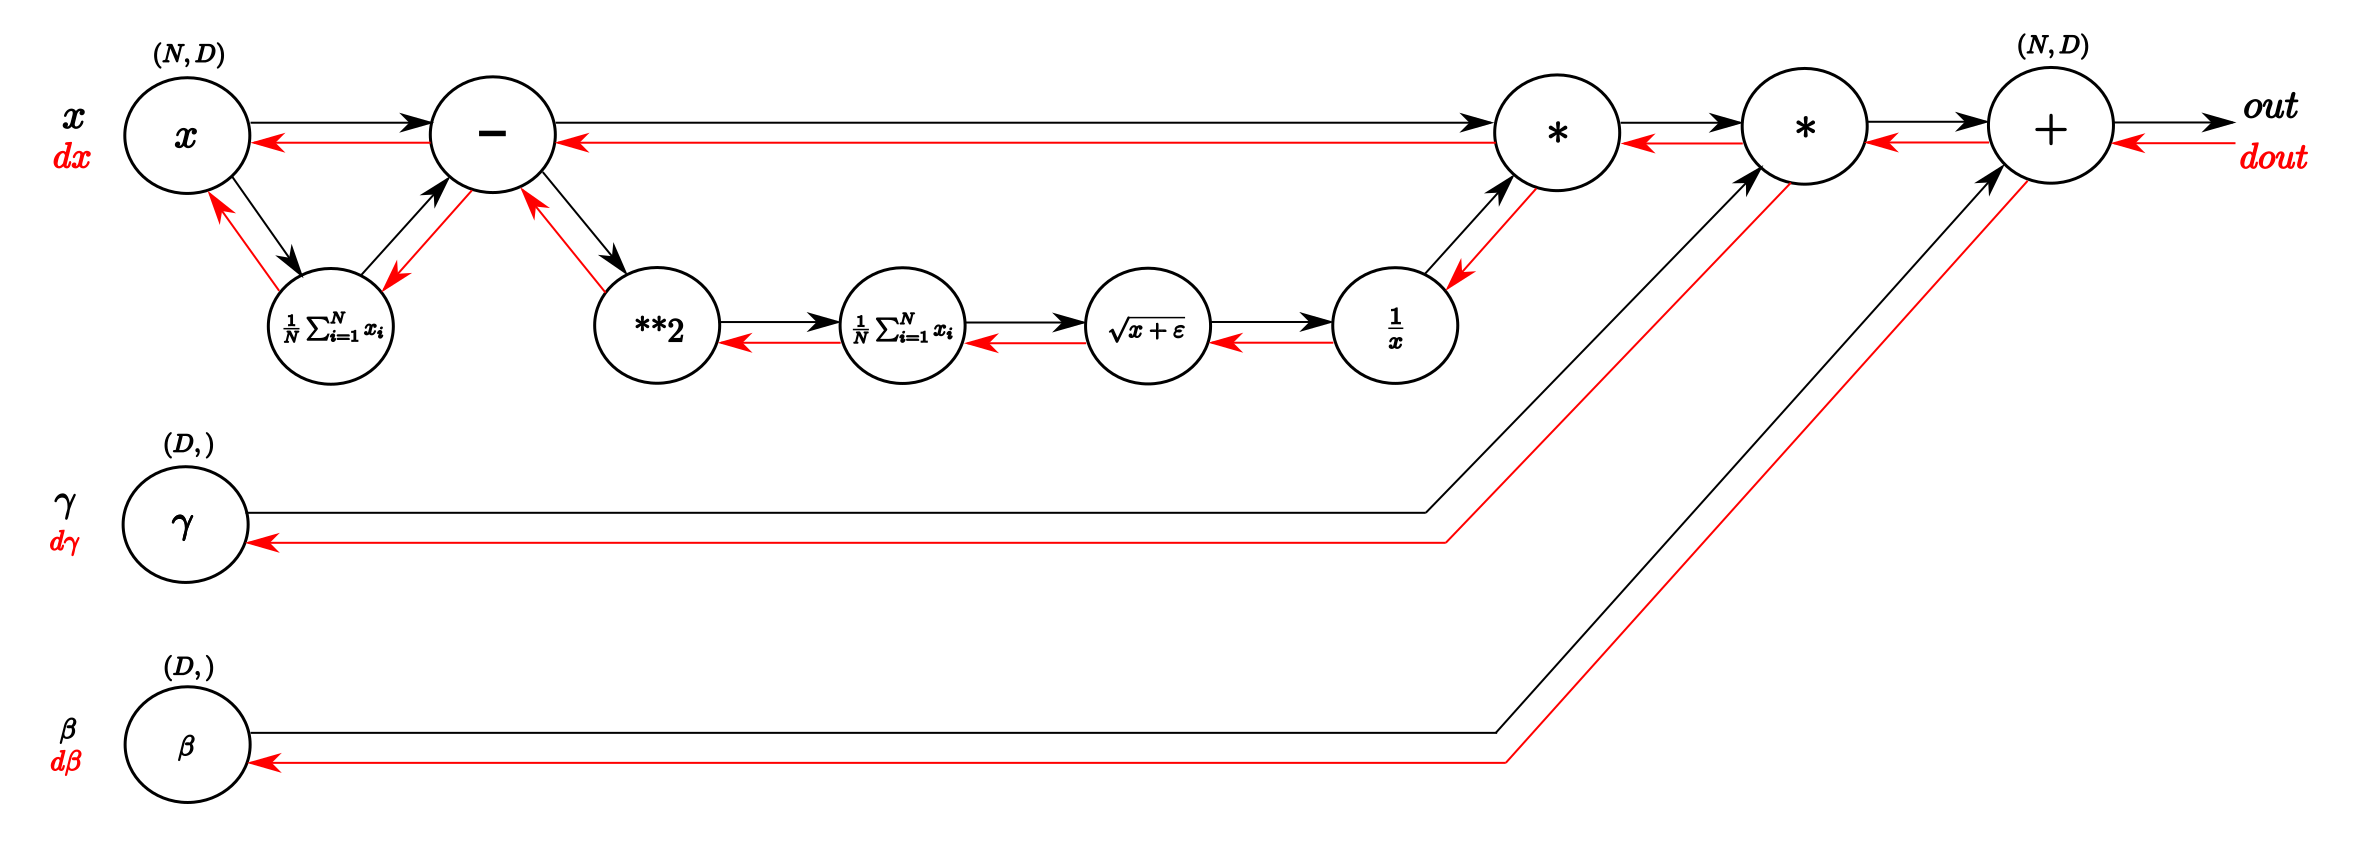

In [13]:
class BatchNormalization:
  """
  http://arxiv.org/abs/1502.03167
  """
  def __init__(self, gamma, beta, momentum=0.9, running_mean=None, running_var=None):
      self.gamma = gamma
      self.beta = beta
      self.momentum = momentum
      self.input_shape = None # Conv 층=4차원, 완전 연결층=2차원

      # 테스트 시 사용하는 평균과 분산(즉, 업데이트 대상)
      self.running_mean = running_mean
      self.running_var = running_var

      # backward 시에 사용하는 중간 데이터
      self.batch_size = None
      self.xc = None
      self.std = None
      self.dgamma = None
      self.dbeta = None

  def forward(self, x, train_flg=True):
      self.input_shape = x.shape
      if x.ndim != 2:
          N, C, H, W = x.shape
          x = x.reshape(N, -1)

      out = self.__forward(x, train_flg)

      return out.reshape(*self.input_shape)


  def __forward(self, x, train_flg):
      if self.running_mean is None:
          N, D = x.shape
          self.running_mean = np.zeros(D)
          self.running_var = np.zeros(D)

      if train_flg:
          mu = x.mean(axis=0)
          xc = x - mu
          var = np.mean(xc**2, axis=0)
          std = np.sqrt(var + 10e-7)
          xn = xc / std

          self.batch_size = x.shape[0]
          self.xc = xc
          self.xn = xn
          self.std = std
          # 평균과 분산의 이동 평균 계산
          self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu
          self.running_var = self.momentum * self.running_var + (1-self.momentum) * var
      else:
          # 추론 과정
          xc = x - self.running_mean
          xn = xc / ((np.sqrt(self.running_var + 10e-7)))

      out = self.gamma * xn + self.beta
      return out


  def backward(self, dout):
      if dout.ndim != 2:
          N, C, H, W = dout.shape
          dout = dout.reshape(N, -1)

      dx = self.__backward(dout)

      dx = dx.reshape(*self.input_shape)
      return dx


  def __backward(self, dout):
      dbeta = dout.sum(axis=0)
      dgamma = np.sum(self.xn * dout, axis=0)
      dxn = self.gamma * dout
      dxc = dxn / self.std
      dstd = -np.sum((dxn * self.xc) / (self.std * self.std), axis=0)
      dvar = 0.5 * dstd / self.std
      dxc += (2.0 / self.batch_size) * self.xc * dvar
      dmu = np.sum(dxc, axis=0)
      dx = dxc - dmu / self.batch_size

      self.dgamma = dgamma
      self.dbeta = dbeta

      return dx

**Dropout**

In [14]:
class Dropout:
    """
    http://arxiv.org/abs/1207.0580
    """
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout * self.mask

# Training

In [15]:
from torchvision import datasets, transforms

cifar10_train = datasets.MNIST(root='./data', train=True, download=True)
cifar10_test = datasets.MNIST(root='./data', train=False, download=True)

# flatten, normalization
x_train = cifar10_train.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_train = cifar10_train.targets
x_test = cifar10_test.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_test = cifar10_test.targets

# y one-hot encodeing
n = len(np.unique(t_train))
t_train = np.eye(n)[t_train]
t_test = np.eye(n)[t_test]

print(f'x_train.shape: {x_train.shape}')
print(f't_train.shape: {t_train.shape}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.48MB/s]


x_train.shape: (60000, 784)
t_train.shape: (60000, 10)


정규화 기법을 하나씩 적용해보고, 그렇지 않은 경우의 결과를 비교해보세요!

epoch:0, train acc:0.03, test acc:0.0524
epoch:1, train acc:0.03666666666666667, test acc:0.0716
epoch:2, train acc:0.07333333333333333, test acc:0.095
epoch:3, train acc:0.08333333333333333, test acc:0.0994
epoch:4, train acc:0.13666666666666666, test acc:0.1208
epoch:5, train acc:0.16666666666666666, test acc:0.1366
epoch:6, train acc:0.19, test acc:0.1565
epoch:7, train acc:0.23333333333333334, test acc:0.1801
epoch:8, train acc:0.2833333333333333, test acc:0.2143
epoch:9, train acc:0.31, test acc:0.2326
epoch:10, train acc:0.35333333333333333, test acc:0.2641
epoch:11, train acc:0.39666666666666667, test acc:0.2906
epoch:12, train acc:0.4266666666666667, test acc:0.2986
epoch:13, train acc:0.46, test acc:0.325
epoch:14, train acc:0.5, test acc:0.3646
epoch:15, train acc:0.53, test acc:0.3872
epoch:16, train acc:0.5766666666666667, test acc:0.4219
epoch:17, train acc:0.5766666666666667, test acc:0.444
epoch:18, train acc:0.5866666666666667, test acc:0.4432
epoch:19, train acc:0.6066

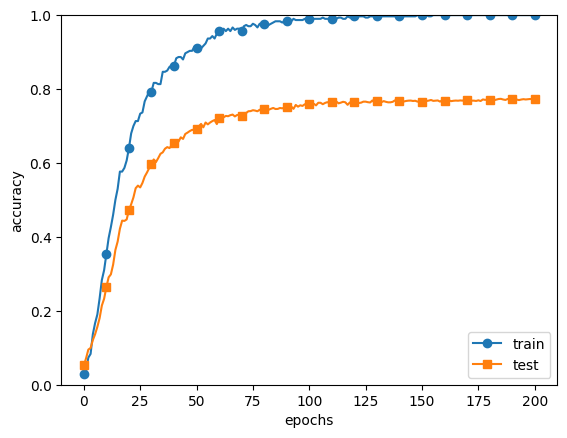

In [18]:
import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.09333333333333334, test acc:0.1032
epoch:1, train acc:0.08666666666666667, test acc:0.1046
epoch:2, train acc:0.09666666666666666, test acc:0.1075
epoch:3, train acc:0.09666666666666666, test acc:0.1161
epoch:4, train acc:0.1, test acc:0.1194
epoch:5, train acc:0.12333333333333334, test acc:0.14
epoch:6, train acc:0.15, test acc:0.1576
epoch:7, train acc:0.18666666666666668, test acc:0.1743
epoch:8, train acc:0.20666666666666667, test acc:0.1896
epoch:9, train acc:0.23666666666666666, test acc:0.2122
epoch:10, train acc:0.2633333333333333, test acc:0.2239
epoch:11, train acc:0.2733333333333333, test acc:0.2413
epoch:12, train acc:0.2833333333333333, test acc:0.2594
epoch:13, train acc:0.32, test acc:0.2778
epoch:14, train acc:0.32666666666666666, test acc:0.2779
epoch:15, train acc:0.3333333333333333, test acc:0.2778
epoch:16, train acc:0.36333333333333334, test acc:0.2908
epoch:17, train acc:0.38, test acc:0.3011
epoch:18, train acc:0.41, test acc:0.3168
epoch:19,

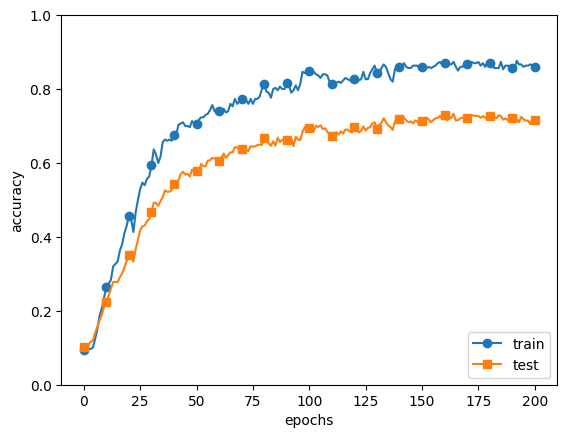

In [19]:
# weight_decay_lambda=0.1

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)

optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.07666666666666666, test acc:0.0837
epoch:1, train acc:0.06666666666666667, test acc:0.0821
epoch:2, train acc:0.06666666666666667, test acc:0.0832
epoch:3, train acc:0.06333333333333334, test acc:0.0857
epoch:4, train acc:0.06666666666666667, test acc:0.0866
epoch:5, train acc:0.07, test acc:0.0872
epoch:6, train acc:0.07666666666666666, test acc:0.0913
epoch:7, train acc:0.08333333333333333, test acc:0.0942
epoch:8, train acc:0.08333333333333333, test acc:0.0963
epoch:9, train acc:0.08666666666666667, test acc:0.0962
epoch:10, train acc:0.08666666666666667, test acc:0.0973
epoch:11, train acc:0.08666666666666667, test acc:0.0985
epoch:12, train acc:0.08666666666666667, test acc:0.1002
epoch:13, train acc:0.09, test acc:0.102
epoch:14, train acc:0.08666666666666667, test acc:0.1031
epoch:15, train acc:0.08333333333333333, test acc:0.104
epoch:16, train acc:0.08333333333333333, test acc:0.1048
epoch:17, train acc:0.09, test acc:0.1053
epoch:18, train acc:0.09, test 

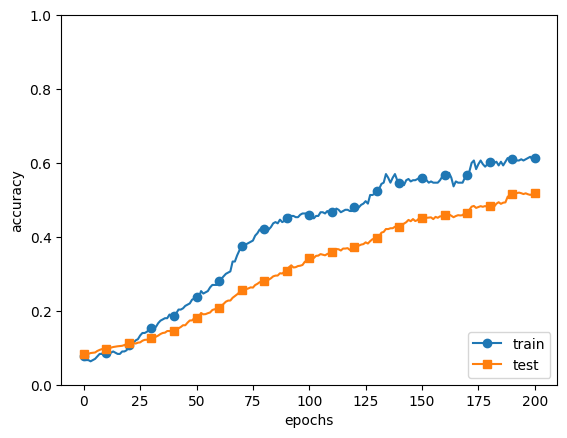

In [21]:
# use_dropout = True, dropout_ration = 0.2

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0, use_dropout = True, dropout_ration = 0.2, use_batchnorm=False)

optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.09666666666666666, test acc:0.0704
epoch:1, train acc:0.11, test acc:0.0721
epoch:2, train acc:0.1, test acc:0.072
epoch:3, train acc:0.13666666666666666, test acc:0.0803
epoch:4, train acc:0.15333333333333332, test acc:0.0974
epoch:5, train acc:0.14666666666666667, test acc:0.1073
epoch:6, train acc:0.16, test acc:0.1202
epoch:7, train acc:0.18, test acc:0.1281
epoch:8, train acc:0.2, test acc:0.1391
epoch:9, train acc:0.20666666666666667, test acc:0.1488
epoch:10, train acc:0.21666666666666667, test acc:0.155
epoch:11, train acc:0.21666666666666667, test acc:0.1677
epoch:12, train acc:0.24333333333333335, test acc:0.1761
epoch:13, train acc:0.24666666666666667, test acc:0.184
epoch:14, train acc:0.2633333333333333, test acc:0.1924
epoch:15, train acc:0.27, test acc:0.1984
epoch:16, train acc:0.29, test acc:0.2071
epoch:17, train acc:0.30333333333333334, test acc:0.2121
epoch:18, train acc:0.31666666666666665, test acc:0.218
epoch:19, train acc:0.35, test acc:0.22

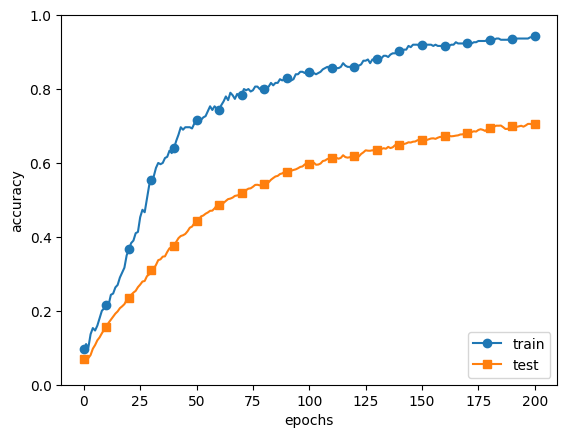

In [22]:
# use_dropout = True, dropout_ration = 0.2, use_batchnorm=True

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0, use_dropout = True, dropout_ration = 0.2, use_batchnorm=True)

optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.1, test acc:0.0837
epoch:1, train acc:0.09666666666666666, test acc:0.0821
epoch:2, train acc:0.1, test acc:0.0839
epoch:3, train acc:0.10333333333333333, test acc:0.0836
epoch:4, train acc:0.10333333333333333, test acc:0.0854
epoch:5, train acc:0.10333333333333333, test acc:0.0881
epoch:6, train acc:0.11, test acc:0.0894
epoch:7, train acc:0.11, test acc:0.0908
epoch:8, train acc:0.11, test acc:0.0921
epoch:9, train acc:0.11, test acc:0.0942
epoch:10, train acc:0.11, test acc:0.0976
epoch:11, train acc:0.11, test acc:0.0949
epoch:12, train acc:0.11, test acc:0.0937
epoch:13, train acc:0.11333333333333333, test acc:0.0973
epoch:14, train acc:0.11333333333333333, test acc:0.103
epoch:15, train acc:0.11333333333333333, test acc:0.1037
epoch:16, train acc:0.11666666666666667, test acc:0.103
epoch:17, train acc:0.12333333333333334, test acc:0.1057
epoch:18, train acc:0.12666666666666668, test acc:0.105
epoch:19, train acc:0.12666666666666668, test acc:0.1083
epoch:20, 

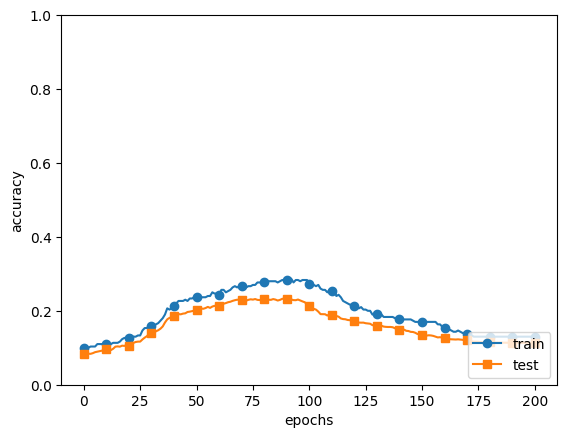

In [23]:
# weight_decay_lambda=0.1, use_dropout = True, dropout_ration = 0.2

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.1, use_dropout = True, dropout_ration = 0.2, use_batchnorm=False)

optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.09333333333333334, test acc:0.0934
epoch:1, train acc:0.08666666666666667, test acc:0.0994
epoch:2, train acc:0.1, test acc:0.1016
epoch:3, train acc:0.08, test acc:0.1072
epoch:4, train acc:0.13, test acc:0.1151
epoch:5, train acc:0.15, test acc:0.1294
epoch:6, train acc:0.17333333333333334, test acc:0.1412
epoch:7, train acc:0.21666666666666667, test acc:0.1574
epoch:8, train acc:0.20333333333333334, test acc:0.1577
epoch:9, train acc:0.22, test acc:0.163
epoch:10, train acc:0.22666666666666666, test acc:0.1698
epoch:11, train acc:0.22, test acc:0.1765
epoch:12, train acc:0.24666666666666667, test acc:0.1864
epoch:13, train acc:0.23666666666666666, test acc:0.1874
epoch:14, train acc:0.2633333333333333, test acc:0.1983
epoch:15, train acc:0.28, test acc:0.2058
epoch:16, train acc:0.2866666666666667, test acc:0.2111
epoch:17, train acc:0.29, test acc:0.2209
epoch:18, train acc:0.30333333333333334, test acc:0.2299
epoch:19, train acc:0.31666666666666665, test acc:0

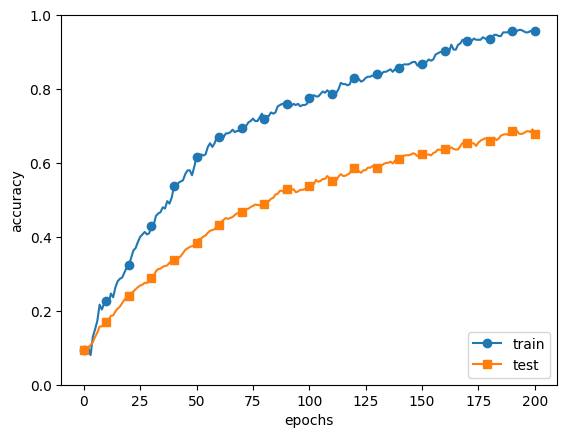

In [24]:
# weight_decay_lambda=0.1, use_dropout = True, dropout_ration = 0.2, use_batchnorm=True

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.1, use_dropout = True, dropout_ration = 0.2, use_batchnorm=True)

optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.06333333333333334, test acc:0.0829
epoch:1, train acc:0.056666666666666664, test acc:0.0833
epoch:2, train acc:0.07333333333333333, test acc:0.0868
epoch:3, train acc:0.07666666666666666, test acc:0.0998
epoch:4, train acc:0.08666666666666667, test acc:0.1063
epoch:5, train acc:0.10333333333333333, test acc:0.1186
epoch:6, train acc:0.11, test acc:0.1299
epoch:7, train acc:0.12333333333333334, test acc:0.137
epoch:8, train acc:0.16, test acc:0.1418
epoch:9, train acc:0.14666666666666667, test acc:0.1477
epoch:10, train acc:0.15666666666666668, test acc:0.152
epoch:11, train acc:0.17333333333333334, test acc:0.1629
epoch:12, train acc:0.20333333333333334, test acc:0.1724
epoch:13, train acc:0.20333333333333334, test acc:0.1801
epoch:14, train acc:0.23333333333333334, test acc:0.1898
epoch:15, train acc:0.24, test acc:0.2018
epoch:16, train acc:0.27666666666666667, test acc:0.2123
epoch:17, train acc:0.2966666666666667, test acc:0.223
epoch:18, train acc:0.3266666666

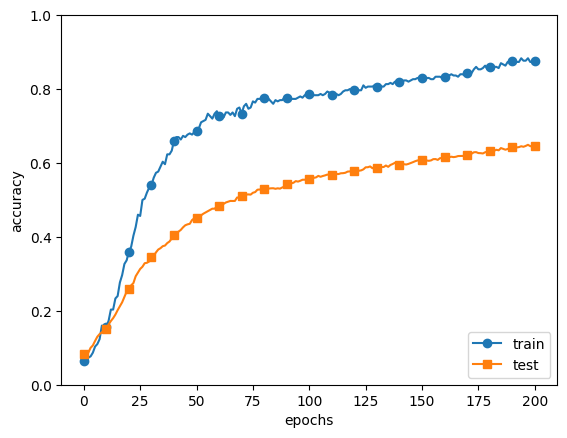

In [26]:
# weight_decay_lambda=0.05, use_dropout = True, dropout_ration = 0.2, use_batchnorm=True

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.05, use_dropout = True, dropout_ration = 0.2, use_batchnorm=True)

optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.08666666666666667, test acc:0.0743
epoch:1, train acc:0.05, test acc:0.0777
epoch:2, train acc:0.06333333333333334, test acc:0.084
epoch:3, train acc:0.08666666666666667, test acc:0.0976
epoch:4, train acc:0.14, test acc:0.1127
epoch:5, train acc:0.2, test acc:0.1322
epoch:6, train acc:0.16, test acc:0.1434
epoch:7, train acc:0.20333333333333334, test acc:0.1566
epoch:8, train acc:0.24, test acc:0.1713
epoch:9, train acc:0.23666666666666666, test acc:0.1805
epoch:10, train acc:0.25666666666666665, test acc:0.1977
epoch:11, train acc:0.26, test acc:0.2079
epoch:12, train acc:0.27, test acc:0.2159
epoch:13, train acc:0.29333333333333333, test acc:0.2245
epoch:14, train acc:0.30333333333333334, test acc:0.2383
epoch:15, train acc:0.29, test acc:0.2445
epoch:16, train acc:0.33, test acc:0.2589
epoch:17, train acc:0.37, test acc:0.2646
epoch:18, train acc:0.39666666666666667, test acc:0.2752
epoch:19, train acc:0.4, test acc:0.282
epoch:20, train acc:0.45, test acc:0.29

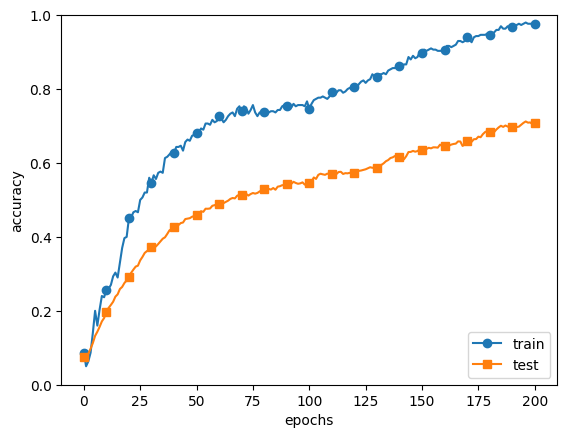

In [27]:
# weight_decay_lambda=0.2, use_dropout = True, dropout_ration = 0.2, use_batchnorm=True

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.2, use_dropout = True, dropout_ration = 0.2, use_batchnorm=True)

optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.18666666666666668, test acc:0.1438
epoch:1, train acc:0.2866666666666667, test acc:0.2097
epoch:2, train acc:0.5333333333333333, test acc:0.4518
epoch:3, train acc:0.8, test acc:0.6515
epoch:4, train acc:0.9, test acc:0.7095
epoch:5, train acc:0.9, test acc:0.7198
epoch:6, train acc:0.9166666666666666, test acc:0.7142
epoch:7, train acc:0.94, test acc:0.7215
epoch:8, train acc:0.9, test acc:0.6707
epoch:9, train acc:0.9, test acc:0.6955
epoch:10, train acc:0.9233333333333333, test acc:0.7238
epoch:11, train acc:0.92, test acc:0.6941
epoch:12, train acc:0.9833333333333333, test acc:0.7662
epoch:13, train acc:0.98, test acc:0.7523
epoch:14, train acc:0.98, test acc:0.7569
epoch:15, train acc:0.9766666666666667, test acc:0.7575
epoch:16, train acc:0.99, test acc:0.7601
epoch:17, train acc:0.99, test acc:0.7654
epoch:18, train acc:0.9933333333333333, test acc:0.7852
epoch:19, train acc:0.9966666666666667, test acc:0.7829
epoch:20, train acc:0.96, test acc:0.7302
epoch:

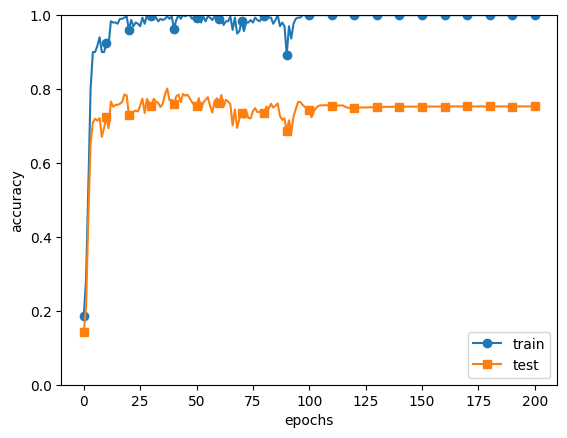

In [20]:
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0, use_dropout = False, dropout_ration = 0, use_batchnorm=False)

optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.09666666666666666, test acc:0.1076
epoch:1, train acc:0.13666666666666666, test acc:0.1207
epoch:2, train acc:0.21, test acc:0.2065
epoch:3, train acc:0.5933333333333334, test acc:0.5397
epoch:4, train acc:0.54, test acc:0.4761
epoch:5, train acc:0.4066666666666667, test acc:0.3187
epoch:6, train acc:0.17666666666666667, test acc:0.1509
epoch:7, train acc:0.11333333333333333, test acc:0.1017
epoch:8, train acc:0.11333333333333333, test acc:0.101
epoch:9, train acc:0.11333333333333333, test acc:0.1018
epoch:10, train acc:0.11333333333333333, test acc:0.101
epoch:11, train acc:0.11333333333333333, test acc:0.1042
epoch:12, train acc:0.11666666666666667, test acc:0.1093
epoch:13, train acc:0.22666666666666666, test acc:0.1746
epoch:14, train acc:0.2, test acc:0.1526
epoch:15, train acc:0.5366666666666666, test acc:0.414
epoch:16, train acc:0.7633333333333333, test acc:0.6444
epoch:17, train acc:0.7366666666666667, test acc:0.61
epoch:18, train acc:0.7033333333333334, 

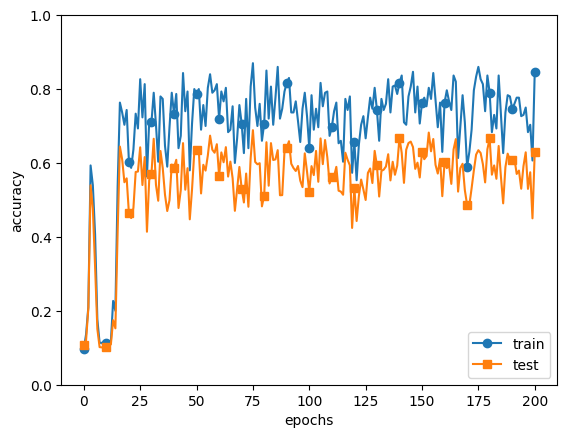

In [28]:
# weight_decay_lambda=0.2, use_dropout = True, dropout_ration = 0.2, use_batchnorm=True, optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.2, use_dropout = True, dropout_ration = 0.2, use_batchnorm=True)

optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.13, test acc:0.1135
epoch:1, train acc:0.10333333333333333, test acc:0.1009
epoch:2, train acc:0.17, test acc:0.1255
epoch:3, train acc:0.08, test acc:0.0841
epoch:4, train acc:0.11333333333333333, test acc:0.0981
epoch:5, train acc:0.11333333333333333, test acc:0.101
epoch:6, train acc:0.11666666666666667, test acc:0.1024
epoch:7, train acc:0.14666666666666667, test acc:0.128
epoch:8, train acc:0.21666666666666667, test acc:0.1903
epoch:9, train acc:0.22666666666666666, test acc:0.2267
epoch:10, train acc:0.25, test acc:0.2398
epoch:11, train acc:0.31, test acc:0.2508
epoch:12, train acc:0.32666666666666666, test acc:0.3127
epoch:13, train acc:0.3433333333333333, test acc:0.3085
epoch:14, train acc:0.41333333333333333, test acc:0.3228
epoch:15, train acc:0.43, test acc:0.3671
epoch:16, train acc:0.51, test acc:0.4037
epoch:17, train acc:0.4866666666666667, test acc:0.3753
epoch:18, train acc:0.47, test acc:0.3902
epoch:19, train acc:0.48, test acc:0.3616
epoch:20,

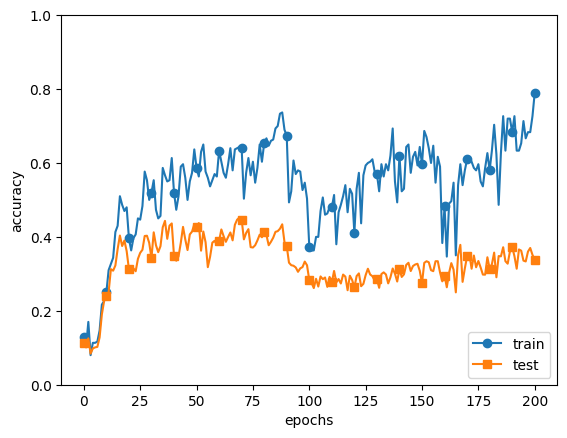

In [29]:
# optimizer = Adam(lr=0.05, beta1=0.9, beta2=0.999)

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0, use_dropout = False, dropout_ration = 0, use_batchnorm=False)

optimizer = Adam(lr=0.05, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()